### 간단한 동작과정 보기위한 test코드

In [ ]:
import torch
from torch import nn

In [ ]:
x=torch.randn(100,3)
layer=nn.Linear(3,5)
print(layer(x).shape)
print(layer.weight)
print(layer.bias)

torch.Size([100, 5])
Parameter containing:
tensor([[ 0.3204, -0.3128, -0.2852],
        [ 0.4886,  0.0832, -0.0778],
        [-0.2936,  0.3773,  0.1360],
        [ 0.3830, -0.1594,  0.2152],
        [-0.2998,  0.1340,  0.0969]], requires_grad=True)
Parameter containing:
tensor([-0.5529,  0.0730, -0.4537, -0.1557,  0.3946], requires_grad=True)


In [ ]:
x=torch.randn(2,5)
layer=nn.ReLU()
print(x)
print(layer(x))

tensor([[ 0.6482,  0.2888, -2.1886,  0.2370, -0.6884],
        [ 1.1622,  0.0327, -0.0510,  0.1310,  0.9863]])
tensor([[0.6482, 0.2888, 0.0000, 0.2370, 0.0000],
        [1.1622, 0.0327, 0.0000, 0.1310, 0.9863]])


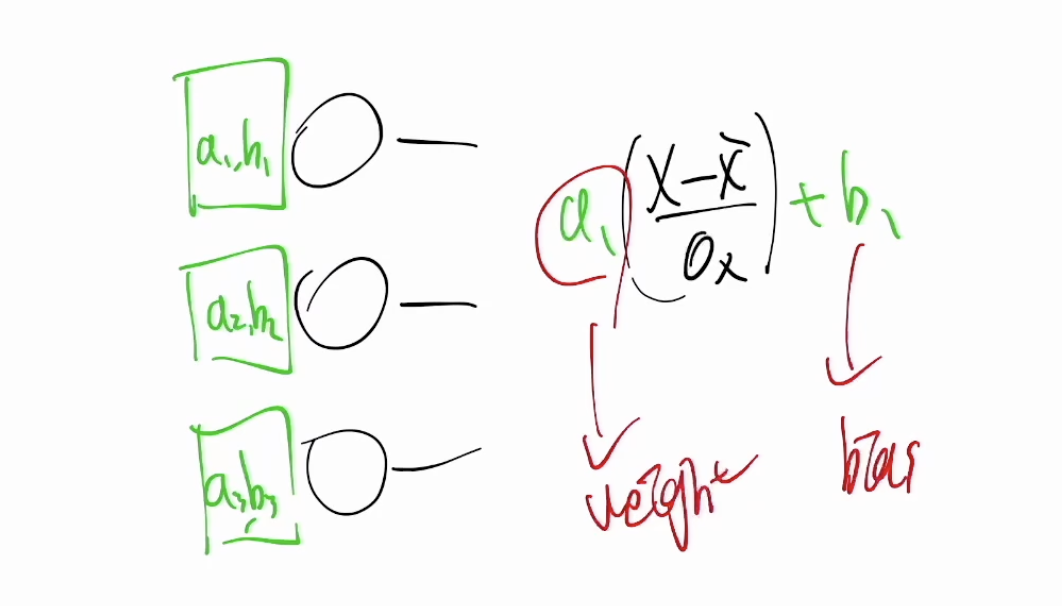

### bachnorm은 처음 파라미터 초기값이 weight=1,bias=0으로 초기화된다. 즉,랜덤초기화가 아니라 평균0,분산1로 초기화(재배치)한다.

In [ ]:
layer=nn.BatchNorm1d(3) #1차원데이터에 대해 
print(layer.weight) # 표준편차
print(layer.bias) # 평균

x = torch.randn(5,3)
print(x)
print(layer(x))
print(layer(x).mean(dim=0))
print(layer(x).std(dim=0, unbiased=False)) # torch.std는 N-1로 나눔

Parameter containing:
tensor([1., 1., 1.], requires_grad=True)
Parameter containing:
tensor([0., 0., 0.], requires_grad=True)
tensor([[ 1.1264,  0.4925,  2.0584],
        [-1.0822,  0.5491, -1.0864],
        [ 0.0822, -0.5143,  1.6888],
        [-1.2817,  0.8717, -1.4581],
        [ 0.1880, -1.3580,  0.9973]])
tensor([[ 1.4873,  0.5862,  1.1210],
        [-1.0014,  0.6548, -1.0573],
        [ 0.3106, -0.6324,  0.8650],
        [-1.2263,  1.0453, -1.3147],
        [ 0.4298, -1.6538,  0.3860]], grad_fn=<NativeBatchNormBackward0>)
tensor([ 0.0000e+00, -2.3842e-08, -2.3842e-08], grad_fn=<MeanBackward1>)
tensor([1.0000, 1.0000, 1.0000], grad_fn=<StdBackward0>)


In [ ]:
layer=nn.LayerNorm(3)
print(layer.weight) # 표준편차
print(layer.bias) # 평균

x = torch.randn(5,3)
print(x)
print(layer(x))
print(layer(x).mean(dim=1))
print(layer(x).std(dim=1, unbiased=False))

Parameter containing:
tensor([1., 1., 1.], requires_grad=True)
Parameter containing:
tensor([0., 0., 0.], requires_grad=True)
tensor([[ 0.4078, -0.2494,  0.1434],
        [ 0.7519, -0.8480,  0.2823],
        [-0.6007, -0.2990,  0.0029],
        [ 0.0140,  0.7382, -0.1563],
        [-0.4574, -0.0778, -1.0623]])
tensor([[ 1.1377e+00, -1.2962e+00,  1.5857e-01],
        [ 1.0273e+00, -1.3553e+00,  3.2800e-01],
        [-1.2245e+00, -3.1615e-04,  1.2248e+00],
        [-4.7606e-01,  1.3913e+00, -9.1519e-01],
        [ 1.8512e-01,  1.1216e+00, -1.3067e+00]],
       grad_fn=<NativeLayerNormBackward0>)
tensor([ 3.4769e-08, -4.9671e-08,  0.0000e+00, -3.9736e-08,  1.5895e-07],
       grad_fn=<MeanBackward1>)
tensor([0.9999, 1.0000, 0.9999, 1.0000, 1.0000], grad_fn=<StdBackward0>)


In [ ]:
layer=nn.BatchNorm2d(3) #2차원 (이미지데이터)에 사용
print(layer.weight) # 표준편차
print(layer.bias) # 평균

x = torch.randn(5,3,32,32)
print(layer(x).mean(dim=(0,2,3)))
print(layer(x).std(dim=(0,2,3), unbiased=False))

Parameter containing:
tensor([1., 1., 1.], requires_grad=True)
Parameter containing:
tensor([0., 0., 0.], requires_grad=True)
tensor([ 1.4901e-09, -1.4901e-09, -2.7940e-10], grad_fn=<MeanBackward1>)
tensor([1.0000, 1.0000, 1.0000], grad_fn=<StdBackward0>)


### Dropout(실제 논문과 구현이 다르다.)
- 논문에서는 test시에 weight에 확률p를 곱하여 사용하지만 실제 구현시에는 training떄 weight에 p를 나누어 사용하고 test시에는 그대로 원래 weight를 사용한다.
- 이렇게 구현하면 장점: 테스트시에 모델을 통과하는데 걸리는 시간은  짧을수록좋기때문에(모델 serving시에는 빠른게 좋음),실제 사용시, 테스트시에 아무것도 건들지않고 그냥 웨이트를 사용한다.
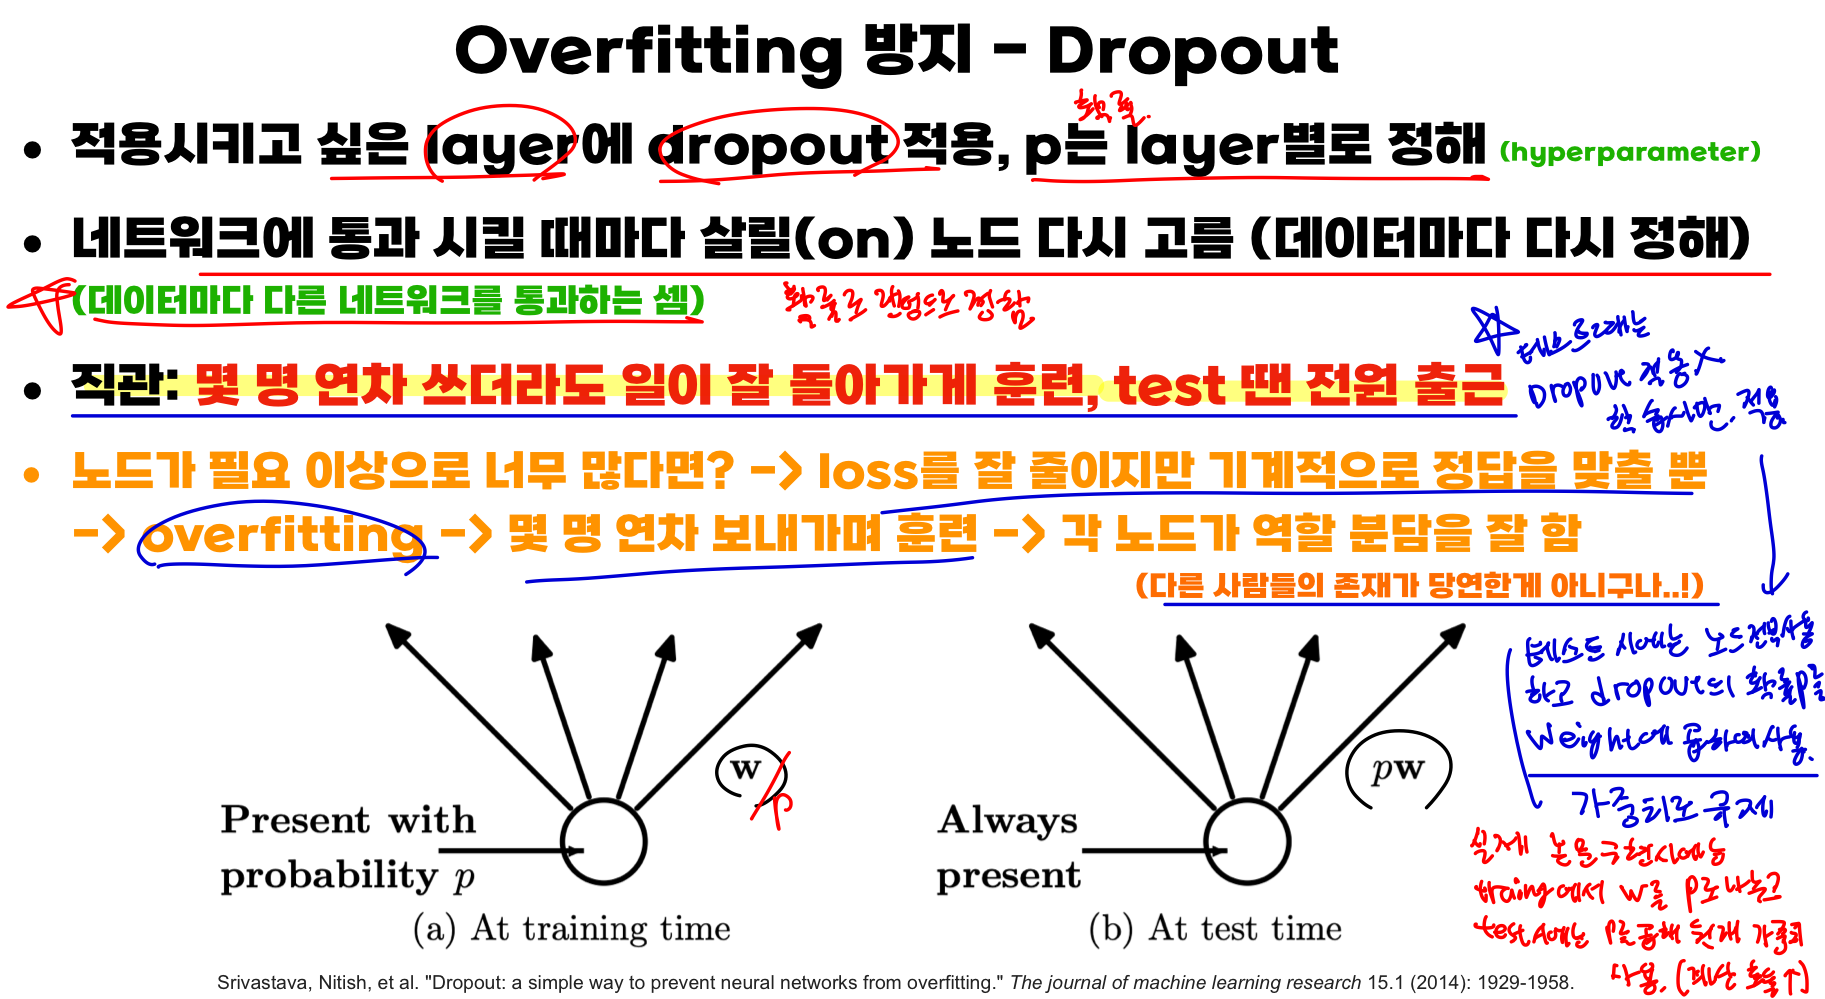

In [ ]:
x = torch.randn(3,7)
drop = nn.Dropout(p=0.9) # 구현에서 p는 죽일 확률, 논문에서는 p는 살릴확률
print(x)
print(drop(x)*(1-0.9)) # 구현은 반대로 훈련 때 1/살릴 확률을 곱하고 테스트 때는 그대로 나오는 것으로!
drop.eval()
print(drop(x))
"""
...
nn.Linear(10,100)
nn.BatcnhNorm1d(100)
nn.ReLU()
nn.Dropout(p=0.5) 이런 식으로 구성!
...
"""

tensor([[ 0.7474,  0.3166, -0.4616, -0.5114,  0.6452,  0.2129,  0.0804],
        [ 0.8921,  0.8428, -0.6437, -0.5576,  1.1614,  1.5143,  1.7939],
        [ 0.4878,  1.0037, -1.5414, -0.3925, -0.5227,  1.0885,  1.8444]])
tensor([[ 0.0000,  0.0000, -0.0000, -0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000, -0.0000, -0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000, -0.0000, -0.3925, -0.0000,  0.0000,  1.8444]])
tensor([[ 0.7474,  0.3166, -0.4616, -0.5114,  0.6452,  0.2129,  0.0804],
        [ 0.8921,  0.8428, -0.6437, -0.5576,  1.1614,  1.5143,  1.7939],
        [ 0.4878,  1.0037, -1.5414, -0.3925, -0.5227,  1.0885,  1.8444]])


'\n...\nnn.Linear(10,100)\nnn.BatcnhNorm1d(100)\nnn.ReLU()\nnn.Dropout(p=0.5) 이런 식으로 구성!\n...\n'

In [ ]:
class sample_model(nn.Module):
    def __init__(self):
        super().__init__()
        self.drop_layer=nn.Sequential(nn.Linear(5,7),
                                      nn.ReLU(),
                                      nn.Dropout(p=0.9))

    def forward(self, x):
        x = self.drop_layer(x)
        return x

model=sample_model()
model.train() # train mode로 전환
x=torch.randn(3,5) # 그 담에 x=torch.randn(2,3,5)
print(model(x))

model.eval()
print(model(x)) # test mode, 일부 0인 이유는 음수인 애들이 ReLU 때문에 사라져서

tensor([[0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.]], grad_fn=<MulBackward0>)
tensor([[0.3704, 0.1151, 0.0000, 0.2269, 0.0000, 0.0000, 0.1081],
        [0.0000, 0.5474, 0.3114, 0.0000, 1.2485, 0.0000, 0.1832],
        [0.5193, 0.0379, 0.0000, 0.1904, 0.0000, 0.0000, 0.0000]],
       grad_fn=<ReluBackward0>)


In [ ]:
# 이건 내 필기용
class sample_model(nn.Module):
    def __init__(self):
        super().__init__()
        self.drop_layer=nn.Sequential(nn.Conv2d(3,3,3),
                                      nn.Dropout2d(p=0.3))
    def forward(self, x):
        x = self.drop_layer(x)
        return x

model=sample_model()
model.train()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)
x=torch.randn(5,3,4,4).to(DEVICE)
model.to(DEVICE)
print(model(x))

cpu
tensor([[[[ 6.7652e-01,  1.3470e+00],
          [-2.5350e-01,  4.2296e-01]],

         [[-8.9535e-02, -5.0801e-01],
          [ 4.7158e-05,  8.9355e-01]],

         [[ 0.0000e+00, -0.0000e+00],
          [ 0.0000e+00, -0.0000e+00]]],


        [[[-0.0000e+00, -0.0000e+00],
          [-0.0000e+00, -0.0000e+00]],

         [[-8.5457e-01,  3.3403e-01],
          [ 5.7593e-01, -1.1464e+00]],

         [[ 1.6245e+00,  3.1388e-01],
          [-5.9892e-01,  7.7086e-01]]],


        [[[ 0.0000e+00, -0.0000e+00],
          [-0.0000e+00, -0.0000e+00]],

         [[-0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00]],

         [[-6.5624e-01,  5.6747e-01],
          [ 6.7451e-01, -1.1913e-01]]],


        [[[ 2.2025e-01,  1.9574e-01],
          [ 3.5988e-02,  1.1717e+00]],

         [[ 0.0000e+00,  0.0000e+00],
          [ 0.0000e+00, -0.0000e+00]],

         [[ 7.8380e-01, -4.2357e-01],
          [-6.6476e-01, -1.5264e+00]]],


        [[[-7.1626e-01,  8.3643e-01],
          [-3.

### conv2d연산 layer
- in_channels = feature map (입력) , 처음 입력 데이터가 RGB컬러값이면 3. 흑백이면 1, 로 설정
- out_channels = feature map(출력)
- kernel_size = 필터사이즈 (정방행렬로 구성)
- stride=1, padding=0 이 디폴트

In [ ]:
layer = nn.Conv2d(in_channels=1, out_channels=2, kernel_size=3) # stride=1, padding=0 이 디폴트
layer(torch.randn(32,1,5,5)).shape
# nn.Linear(3,5) # 채채 # 근데 얘는 채 또는 개채를 원함, 개x3 => 개x5
# nn.Conv2d(3,5) # 채채 # 근데 얘는 채행열 또는 개채행열을 원함, 개x3x행x열 => 개x5x행x열

torch.Size([32, 2, 3, 3])

In [ ]:
layer = nn.Conv2d(3,5,3) # weight(=필터=커널)가 3x3x3 짜리 5개(out채널수 맞춤) 존재 (5x3x3x3)
print(layer(torch.randn(32,3,5,5)).shape)
print(layer.weight.shape)

torch.Size([32, 5, 3, 3])
torch.Size([5, 3, 3, 3])


In [ ]:
conv1 = nn.Conv2d(1,8,6, stride=2)
x=torch.randn(32,1,28,28)
print(conv1(x).shape)

conv2 = nn.Conv2d(8,16,3,padding=1)
print(conv2(conv1(x)).shape)

Maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
print(Maxpool(conv2(conv1(x))).shape)

torch.Size([32, 8, 12, 12])
torch.Size([32, 16, 12, 12])
torch.Size([32, 16, 6, 6])


### stride를 1로 설정하면 pooling해도 feature map 사이즈 안변함

In [ ]:
maxpool=nn.MaxPool2d(2) # 2 로만 줘도 자동 kernel_size=2, stride=2
x=torch.randn(1,6,6)
print(x)
print(maxpool(x))
print(maxpool(torch.randn(32,3,6,6)).shape)

tensor([[[ 2.1905,  0.0602, -0.2727,  1.2438, -0.8404, -1.2446],
         [-1.5005, -0.5287,  0.2102,  0.1698, -1.6265, -1.7277],
         [ 0.8562,  0.2485, -0.5648,  0.5806, -0.7994,  0.3133],
         [ 0.6783, -1.1733,  0.3595, -0.1794, -1.1952, -2.6541],
         [-1.1812, -2.0516,  0.2177,  0.7153, -1.0753, -0.4183],
         [-0.7223, -2.0706,  0.3510, -0.4237,  0.0838, -0.7249]]])
tensor([[[ 2.1905,  1.2438, -0.8404],
         [ 0.8562,  0.5806,  0.3133],
         [-0.7223,  0.7153,  0.0838]]])
torch.Size([32, 3, 3, 3])


In [ ]:
maxpool=nn.AvgPool2d(2)
x=torch.randn(1,6,6)
print(x)
print(maxpool(x))
print(maxpool(torch.randn(32,3,6,6)).shape)

tensor([[[-0.1014,  0.0638, -0.6058,  1.0282, -0.6160, -1.2563],
         [-1.2128, -1.6262, -0.5534, -0.4428,  0.6205, -0.3608],
         [ 0.8739, -0.7826, -1.4375, -2.4283, -0.1861, -0.2463],
         [ 0.0351, -0.3134,  0.1746, -0.3673, -1.6950, -0.6430],
         [-0.7272,  0.6347, -0.3968, -0.6013,  0.0740, -1.1834],
         [-0.0225,  0.4944,  0.4879,  0.7797, -0.3787,  0.6691]]])
tensor([[[-0.7192, -0.1434, -0.4031],
         [-0.0468, -1.0146, -0.6926],
         [ 0.0948,  0.0674, -0.2048]]])
torch.Size([32, 3, 3, 3])


In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1,8,6, stride=2) #feature map이 1개에서 8개로
        self.conv2 = nn.Conv2d(8,16,3, padding=1)
        self.Maxpool = nn.MaxPool2d(2)
        self.fc = nn.Linear(16*6*6,10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.Maxpool(x)
        x = torch.flatten(x, start_dim=1)
        x = self.fc(x) #cnn결과 feature map을 flatten후에 mlp통과
        return x

x = torch.randn(32,1,28,28)
model = CNN()
print(model(x).shape)

torch.Size([32, 10])


In [ ]:
# 내 필기용
rnn_cell=nn.RNN(input_size=4, hidden_size=5, batch_first=True) # activation = tanh 도 포함되어있음

x = torch.randn(3,2,4) # batch (batch_first=True 라서 맨 앞), 단어 수, 단어 하나에 대한 벡터 사이즈
out, h = rnn_cell(x)

print(out.shape) # 각 단어에 대해 h 나옴
# batch_first=True 라서 (batch, 단어 수, hidden_size) <= nn.Linear 랑 생각 방식이 똑같음
print(h.shape) # 단어 다 넣고 나서 최종 h
# (D*num_layer(bidirection 이면 D=2), batch_size, hidden_size)

Wx=rnn_cell.weight_ih_l0
Wh=rnn_cell.weight_hh_l0
bx=rnn_cell.bias_ih_l0
bh=rnn_cell.bias_hh_l0

h_init=torch.zeros(1,5)
h0=torch.tanh(x[0,0,:].unsqueeze(dim=0)@Wx.T+bx+h_init@Wh.T+bh)
h1=torch.tanh(x[0,1,:].unsqueeze(dim=0)@Wx.T+bx+h0@Wh.T+bh)
print(h0)
print(h1)

print(out)
print(h)

torch.Size([3, 2, 5])
torch.Size([1, 3, 5])
tensor([[-0.0595, -0.1404,  0.1223, -0.1850, -0.5301]],
       grad_fn=<TanhBackward0>)
tensor([[ 0.8155, -0.2650, -0.0132, -0.8571, -0.3071]],
       grad_fn=<TanhBackward0>)
tensor([[[-0.0595, -0.1404,  0.1223, -0.1850, -0.5301],
         [ 0.8155, -0.2650, -0.0132, -0.8571, -0.3071]],

        [[ 0.7440, -0.0904,  0.6424, -0.0518, -0.1507],
         [ 0.0624, -0.3158,  0.5211, -0.0616, -0.2584]],

        [[ 0.3916,  0.0390,  0.5353,  0.1917, -0.1145],
         [-0.0281,  0.1267,  0.0659, -0.2216,  0.3038]]],
       grad_fn=<TransposeBackward1>)
tensor([[[ 0.8155, -0.2650, -0.0132, -0.8571, -0.3071],
         [ 0.0624, -0.3158,  0.5211, -0.0616, -0.2584],
         [-0.0281,  0.1267,  0.0659, -0.2216,  0.3038]]],
       grad_fn=<StackBackward0>)


## 딥러닝 고수 되기 .parameters() & .modules() & .children()

In [ ]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Sequential(nn.Linear(2,3),
                                 nn.ReLU())
        self.fc2 = nn.Sequential(nn.Linear(3,4),
                                 nn.ReLU())
        self.fc_out = nn.Sequential(nn.Linear(4,1),
                                    nn.Sigmoid())
    def forward(self,x):
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc_out(x)
        return x

model = MLP()
print(model(torch.randn(2,2)).shape)
print(model)

torch.Size([2, 1])
MLP(
  (fc1): Sequential(
    (0): Linear(in_features=2, out_features=3, bias=True)
    (1): ReLU()
  )
  (fc2): Sequential(
    (0): Linear(in_features=3, out_features=4, bias=True)
    (1): ReLU()
  )
  (fc_out): Sequential(
    (0): Linear(in_features=4, out_features=1, bias=True)
    (1): Sigmoid()
  )
)


In [ ]:
model.parameters() #모델의 각 파라미터를 가지고있음

<generator object Module.parameters at 0x7ace3f107300>

In [ ]:
list(model.parameters())[3]
# [layer0 weight 값, layer0 bias 값, layer1 weight 값, layer1 bias 값, ...]

Parameter containing:
tensor([-0.4509,  0.1601, -0.1297,  0.3702], requires_grad=True)

In [ ]:
# for tranfer learning
model = MLP()
print([p for p in model.parameters() if p.requires_grad]) #requires_grad가 True인애들만 학습가능

for p in model.parameters(): # 전체 freeze
    p.requires_grad = False #파라미터 학습 x
model.fc_out = nn.Linear(4,10) # 이진 분류에서 열 개 분류로! ->기존모델에서 fc_out부분 교체

params = [p for p in model.parameters() if p.requires_grad] #교체된 모델의 마지막 부분만 requires_grad가 True로 학습가능
print(params)

from torch import optim
optimizer = optim.Adam(params, lr=0.1) #requires_grad가 True인 파라미터들만 최적화 진행

[Parameter containing:
tensor([[-0.5637, -0.3044],
        [ 0.6015, -0.5894],
        [ 0.3782,  0.5977]], requires_grad=True), Parameter containing:
tensor([ 0.4869, -0.1130, -0.2702], requires_grad=True), Parameter containing:
tensor([[-0.3208, -0.3976, -0.0912],
        [-0.3119, -0.4562,  0.4785],
        [-0.1245, -0.0842, -0.5524],
        [ 0.3453,  0.1335,  0.2311]], requires_grad=True), Parameter containing:
tensor([ 0.2268, -0.5688,  0.0450, -0.5063], requires_grad=True), Parameter containing:
tensor([[ 0.4151, -0.4931, -0.1143, -0.3162]], requires_grad=True), Parameter containing:
tensor([0.1356], requires_grad=True)]
[Parameter containing:
tensor([[ 0.4612, -0.2358, -0.1093, -0.0565],
        [ 0.2043,  0.0255,  0.1952, -0.0662],
        [-0.2598,  0.1299, -0.1431, -0.1583],
        [-0.0767, -0.1508,  0.1460,  0.4769],
        [ 0.4679,  0.1366,  0.3710, -0.3031],
        [ 0.1583,  0.1268,  0.4410,  0.2937],
        [ 0.3710, -0.3226,  0.4266,  0.3314],
        [-0.4086,

In [ ]:
# for tranfer learning (마지막 층은 교체, 그 전 층은 학습시키자)ㅣ 일부분만 freeze
model = MLP()
print([p for p in model.parameters() if p.requires_grad])

for p in list(model.parameters())[:-4]: # 마지막 전 층 전까지만 freeze, 파라미터 리스트중에서 뒤에서 4번쨰면 마지막 전층layer의 파라미터포함x, 리스트형태로 바꾼다음 모델의 파라미터를 freeze할 layer까지만 requires_grad = False로
    p.requires_grad = False
model.fc_out = nn.Linear(4,10) # 이진 분류에서 열 개 분류로!

params = [p for p in model.parameters() if p.requires_grad]
print(params)

from torch import optim
optimizer = optim.Adam(params, lr=0.1)

[Parameter containing:
tensor([[ 0.3345,  0.0655],
        [-0.6561,  0.2372],
        [-0.0440,  0.3570]], requires_grad=True), Parameter containing:
tensor([0.6709, 0.1470, 0.4487], requires_grad=True), Parameter containing:
tensor([[-0.0516, -0.5424, -0.3385],
        [ 0.1927,  0.0710, -0.3572],
        [-0.4345,  0.1020,  0.4130],
        [ 0.1670,  0.2413,  0.5476]], requires_grad=True), Parameter containing:
tensor([ 0.2358, -0.3624, -0.2755, -0.5434], requires_grad=True), Parameter containing:
tensor([[-0.0645, -0.3288, -0.2704,  0.0800]], requires_grad=True), Parameter containing:
tensor([-0.0135], requires_grad=True)]
[Parameter containing:
tensor([[-0.0516, -0.5424, -0.3385],
        [ 0.1927,  0.0710, -0.3572],
        [-0.4345,  0.1020,  0.4130],
        [ 0.1670,  0.2413,  0.5476]], requires_grad=True), Parameter containing:
tensor([ 0.2358, -0.3624, -0.2755, -0.5434], requires_grad=True), Parameter containing:
tensor([[ 0.4283,  0.3287,  0.0245, -0.1159],
        [-0.007

In [ ]:
list(model.named_parameters())[1]
# [('layer0.weight', weight 값), ('layer0.bias', bias 값), ('layer1.weight', weight 값), ('layer1.bias', bias 값), ...] <= 튜플 품은 리스트

('fc1.0.bias',
 Parameter containing:
 tensor([0.6709, 0.1470, 0.4487]))

In [ ]:
for name, p in model.named_parameters(): #튜플로 가져오니 for문시 2개변수로 받아야함
    print(name)
    print(p)

fc1.0.weight
Parameter containing:
tensor([[ 0.3345,  0.0655],
        [-0.6561,  0.2372],
        [-0.0440,  0.3570]])
fc1.0.bias
Parameter containing:
tensor([0.6709, 0.1470, 0.4487])
fc2.0.weight
Parameter containing:
tensor([[-0.0516, -0.5424, -0.3385],
        [ 0.1927,  0.0710, -0.3572],
        [-0.4345,  0.1020,  0.4130],
        [ 0.1670,  0.2413,  0.5476]], requires_grad=True)
fc2.0.bias
Parameter containing:
tensor([ 0.2358, -0.3624, -0.2755, -0.5434], requires_grad=True)
fc_out.weight
Parameter containing:
tensor([[ 0.4283,  0.3287,  0.0245, -0.1159],
        [-0.0071,  0.3589, -0.4997,  0.2204],
        [-0.0726,  0.4301, -0.1611, -0.3376],
        [ 0.4805,  0.3479,  0.3731, -0.1483],
        [-0.4419, -0.3124, -0.0962,  0.4940],
        [ 0.1555, -0.0870,  0.2694, -0.3481],
        [ 0.1656,  0.4329, -0.0102,  0.2485],
        [-0.3599,  0.4798, -0.1792,  0.3533],
        [-0.2008, -0.1797, -0.2835, -0.0872],
        [-0.2081, -0.3122, -0.2959, -0.2760]], requires_grad=T

In [ ]:
model.modules() #weight initialization시에 많이 사용, 모델이 가진 모든 모듈을 불러온다.

<generator object Module.modules at 0x7ace305649e0>

In [ ]:
list(model.modules())

[MLP(
   (fc1): Sequential(
     (0): Linear(in_features=2, out_features=3, bias=True)
     (1): ReLU()
   )
   (fc2): Sequential(
     (0): Linear(in_features=3, out_features=4, bias=True)
     (1): ReLU()
   )
   (fc_out): Linear(in_features=4, out_features=10, bias=True)
 ),
 Sequential(
   (0): Linear(in_features=2, out_features=3, bias=True)
   (1): ReLU()
 ),
 Linear(in_features=2, out_features=3, bias=True),
 ReLU(),
 Sequential(
   (0): Linear(in_features=3, out_features=4, bias=True)
   (1): ReLU()
 ),
 Linear(in_features=3, out_features=4, bias=True),
 ReLU(),
 Linear(in_features=4, out_features=10, bias=True)]

#### modules()를 사용한 weight initialization
- isinstance()사용해서 안에 객체로 만들어진 인스턴스인 경우 True반환 , 이를 사용해서 해당 모듈로 만들어진 파라미터들을 선택하여 initalization

In [ ]:
print([m for m in model.modules() if isinstance(m,nn.Linear)]) #nn.Linear클래스로 만들어진 인스턴스 모듈
print([m.weight for m in model.modules() if isinstance(m,nn.Linear)]) #nn.Linear클래스로 만들어진 인스턴스 모듈 중 weight선택
print([m.weight.grad for m in model.modules() if isinstance(m,nn.Linear)]) #nn.Linear클래스로 만들어진 인스턴스 모듈 중 gradient선택

[Linear(in_features=2, out_features=3, bias=True), Linear(in_features=3, out_features=4, bias=True), Linear(in_features=4, out_features=10, bias=True)]
[Parameter containing:
tensor([[ 0.3345,  0.0655],
        [-0.6561,  0.2372],
        [-0.0440,  0.3570]]), Parameter containing:
tensor([[-0.0516, -0.5424, -0.3385],
        [ 0.1927,  0.0710, -0.3572],
        [-0.4345,  0.1020,  0.4130],
        [ 0.1670,  0.2413,  0.5476]], requires_grad=True), Parameter containing:
tensor([[ 0.4283,  0.3287,  0.0245, -0.1159],
        [-0.0071,  0.3589, -0.4997,  0.2204],
        [-0.0726,  0.4301, -0.1611, -0.3376],
        [ 0.4805,  0.3479,  0.3731, -0.1483],
        [-0.4419, -0.3124, -0.0962,  0.4940],
        [ 0.1555, -0.0870,  0.2694, -0.3481],
        [ 0.1656,  0.4329, -0.0102,  0.2485],
        [-0.3599,  0.4798, -0.1792,  0.3533],
        [-0.2008, -0.1797, -0.2835, -0.0872],
        [-0.2081, -0.3122, -0.2959, -0.2760]], requires_grad=True)]
[None, None, None]


In [ ]:
# weight initialization에 활용
for m in model.modules(): #모델의 전체 모듈중에 세분화로 들어가면서 
    if isinstance(m, nn.Linear): #nn.Linear로 만들어진 인스턴스라면 kaiming_normal_로 초기화
        nn.init.kaiming_normal_(m.weight)
        # nn.init.constant_(m.weight, 1)

print([m.weight for m in model.modules() if isinstance(m, nn.Linear)])

[Parameter containing:
tensor([[ 1.0300, -1.6824],
        [ 1.5611,  1.0557],
        [-0.5092,  0.8284]]), Parameter containing:
tensor([[-0.0588,  0.3189, -0.4368],
        [-0.2273, -0.7067,  0.2402],
        [-0.2946, -0.7301, -0.2429],
        [ 0.1187,  1.2272,  0.4640]], requires_grad=True), Parameter containing:
tensor([[-0.7834, -0.0422, -0.2384,  0.0404],
        [ 0.4944,  0.3431,  0.3428,  0.0781],
        [-1.4183,  0.1368, -0.4978, -0.0176],
        [ 0.0137,  0.6622, -0.3162,  0.9533],
        [-0.6462,  0.1824,  0.2008, -0.7051],
        [-0.3512,  0.2880, -0.8700, -0.9310],
        [-0.0622,  0.0779,  0.8520,  0.2384],
        [ 0.0022, -0.0352,  1.1592, -0.2769],
        [-0.2397,  0.1121,  0.3406, -0.8106],
        [-1.1050,  0.0714, -0.2894, -0.0992]], requires_grad=True)]


In [ ]:
model.children() #클래스 객체의 속성을 선택가능

<generator object Module.children at 0x7ace3efd1620>

In [ ]:
list(model.children()) 

[Sequential(
   (0): Linear(in_features=2, out_features=3, bias=True)
   (1): ReLU()
 ),
 Sequential(
   (0): Linear(in_features=3, out_features=4, bias=True)
   (1): ReLU()
 ),
 Linear(in_features=4, out_features=10, bias=True)]

In [ ]:
x = torch.randn(2,2)
list(model.children())[0](x) #모델의 일부분 block만 어떻게 하거나 통과시키고 싶을떄 사용

tensor([[1.4006, 0.0000, 0.0894],
        [4.4117, 1.1192, 0.0000]])

In [ ]:
sub_network = nn.Sequential(*list(model.children())[:2]) #모델의 일부분 block만 어떻게 하거나 통과시키고 싶을떄 사용,or 모델의 일부분만 가지고 subnetwork를 만들떄 사용
print(sub_network)
sub_network(x)

Sequential(
  (0): Sequential(
    (0): Linear(in_features=2, out_features=3, bias=True)
    (1): ReLU()
  )
  (1): Sequential(
    (0): Linear(in_features=3, out_features=4, bias=True)
    (1): ReLU()
  )
)


tensor([[0.1144, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.0000, 0.0000, 1.3539]], grad_fn=<ReluBackward0>)

In [ ]:
# 내 필기용
# def get_activation(name):
#     def hook(model, input, output):
#         activation[name] = output.detach()
#     return hook

# model.fcs1.register_forward_hook(get_activation('fcs1'))

## Sequential vs ModuleList

In [ ]:
fc=nn.Linear(3,3)
layer_list = [fc for _ in range(5)]
layers1 = nn.Sequential(*layer_list)
layers2 = nn.ModuleList(layer_list)
print(layers1)
print(layers2)

x=torch.randn(1,3)
print(layers1(x))

# print(layers2(x)) # error!
for layer in layers2: #ModuleList는 하나하나 모듈에 입력해야함
    x = layer(x)
print(x)

Sequential(
  (0): Linear(in_features=3, out_features=3, bias=True)
  (1): Linear(in_features=3, out_features=3, bias=True)
  (2): Linear(in_features=3, out_features=3, bias=True)
  (3): Linear(in_features=3, out_features=3, bias=True)
  (4): Linear(in_features=3, out_features=3, bias=True)
)
ModuleList(
  (0-4): 5 x Linear(in_features=3, out_features=3, bias=True)
)
tensor([[0.3293, 0.1672, 0.2470]], grad_fn=<AddmmBackward0>)
tensor([[0.3293, 0.1672, 0.2470]], grad_fn=<AddmmBackward0>)


### 아래는 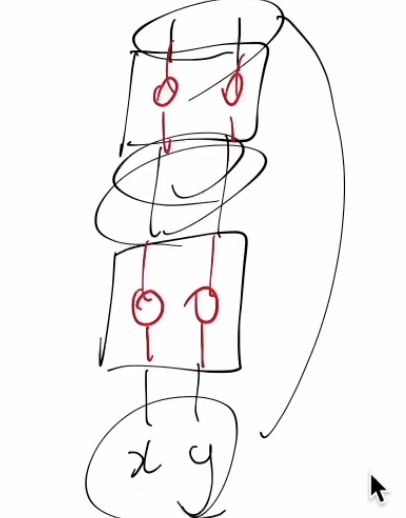 상황 구현 (2개의 입력을 받아 2개의 출력을 내고싶을떄는 Sequential말고 ModuleList사용 )

In [ ]:
# 그럼 nn.Sequential 쓰고 말지 왜 굳이 nn.ModuleList? ->2개입력을 받고 2개출력을 내고싶을떄,Sequential은 입력 한개만 받아서 못씀, ModuleList는 각각 반복문을 통해 통과시키면되서 가능함
class small_block(nn.Module):
    def __init__(self):
        super().__init__()
        self.block_x = nn.Linear(1,1)
        self.block_y = nn.Linear(1,1)

    def forward(self, x, y):
        x = self.block_x(x)
        y = self.block_y(y)
        return x, y

model = nn.Sequential(small_block(),
                      small_block())
# model(torch.randn(1),torch.randn(1)) # error!
# nn.Sequential 이 가지고 있는 forward 함수를 call 하기 때문에 입력을 두 개 넣으면 안 된다!!

model = nn.ModuleList([small_block(),
                       small_block()])
x = torch.randn(1)
y = torch.randn(1)
for block in model:
    x, y = block(x,y)
print(x, y)

tensor([-0.4115], grad_fn=<ViewBackward0>) tensor([-0.9342], grad_fn=<ViewBackward0>)


In [ ]:
# 걍 리스트 쓰지 왜 nn.ModuleList 를 쓸까?
class testNet(nn.Module):
    def __init__(self):
        super().__init__()

        # self.Module_List = [nn.Linear(3,3), nn.Linear(3,3)]
        self.Module_List = nn.ModuleList([nn.Linear(3,3), nn.Linear(3,3)])

    def forward(self,x):
        for layer in self.Module_List:
            x = layer(x)
        return x

model=testNet()
print(model(torch.randn(1,3))) # 통과까진 문제 없음

print(model) # 그냥 리스트로 하니 아무것도 등록이 안 돼 있다!

optimizer = optim.Adam(model.parameters(), lr = 0.1) # 그냥 리스트로 사용해서 등록이 안 돼 있으면 parameter를 못 찾는다!

tensor([[-0.1564,  0.2218, -0.1784]], grad_fn=<AddmmBackward0>)
testNet(
  (Module_List): ModuleList(
    (0-1): 2 x Linear(in_features=3, out_features=3, bias=True)
  )
)


### 모델이 gpu에 올라갔나 확인 코드

In [ ]:
# next(load_model.parameters()).is_cuda # 내 필기용: 모델이 gpu에 올라갔나 확인

# Transposed convolution (내 필기용) ->U-net

In [ ]:
import torch
from torch import nn

up = nn.ConvTranspose2d(1, 1, kernel_size=3, stride=3, padding=0, bias=False)
up.weight.requires_grad=False
up.weight.data = torch.tensor([[[[1.,2,3],[1,2,3],[1,2,3]]]])
x = torch.tensor([[[1.,2],[1,2]]])
print(up(x)) # Conv2d는 corr이지만 ConvTranspose2d 는 conv다!

up = nn.ConvTranspose2d(1, 1, kernel_size=3, stride=2, padding=0, bias=False)
up.weight.requires_grad=False
up.weight.data = torch.tensor([[[[1.,2,3],[1,2,3],[1,2,3]]]])
x = torch.tensor([[[1.,2],[1,2]]])
print(up(x)) # Conv2d는 corr이지만 ConvTranspose2d 는 conv다!

tensor([[[1., 2., 3., 2., 4., 6.],
         [1., 2., 3., 2., 4., 6.],
         [1., 2., 3., 2., 4., 6.],
         [1., 2., 3., 2., 4., 6.],
         [1., 2., 3., 2., 4., 6.],
         [1., 2., 3., 2., 4., 6.]]])
tensor([[[ 1.,  2.,  5.,  4.,  6.],
         [ 1.,  2.,  5.,  4.,  6.],
         [ 2.,  4., 10.,  8., 12.],
         [ 1.,  2.,  5.,  4.,  6.],
         [ 1.,  2.,  5.,  4.,  6.]]])


## kernel_size 및 padding에 따라

In [ ]:
up = nn.ConvTranspose2d(1, 1, kernel_size=5, stride=2, padding=0, bias=False)
up.weight.requires_grad=False
up.weight.data = torch.tensor([[[[1.,2,3,4,5],[1,2,3,4,5],[1,2,3,4,5],[1,2,3,4,5],[1,2,3,4,5]]]])
x = torch.tensor([[[1.,2],[1,2]]])
print(up(x)) # 벌리는건 stride에 의해, zero padding은 kernel_size에 의해 결정

up = nn.ConvTranspose2d(1, 1, kernel_size=4, stride=2, padding=0, bias=False)
up.weight.requires_grad=False
up.weight.data = torch.tensor([[[[1.,2,3,4],[1,2,3,4],[1,2,3,4],[1,2,3,4]]]])
x = torch.tensor([[[1.,2],[1,2]]])
print(up(x)) # kernel_size가 짝수면? 사실 padding이이 위왼쪽에 두줄인지 오른쪽 아래에 두줄인지는 중요하지 않음. 결과는 같다!

up = nn.ConvTranspose2d(1, 1, kernel_size=5, stride=2, padding=2, bias=False)
up.weight.requires_grad=False
up.weight.data = torch.tensor([[[[1.,2,3,4,5],[1,2,3,4,5],[1,2,3,4,5],[1,2,3,4,5],[1,2,3,4,5]]]])
x = torch.tensor([[[1.,2],[1,2]]])
print(up(x)) # padding option은 output에서 지우기

tensor([[[ 1.,  2.,  5.,  8., 11.,  8., 10.],
         [ 1.,  2.,  5.,  8., 11.,  8., 10.],
         [ 2.,  4., 10., 16., 22., 16., 20.],
         [ 2.,  4., 10., 16., 22., 16., 20.],
         [ 2.,  4., 10., 16., 22., 16., 20.],
         [ 1.,  2.,  5.,  8., 11.,  8., 10.],
         [ 1.,  2.,  5.,  8., 11.,  8., 10.]]])
tensor([[[ 1.,  2.,  5.,  8.,  6.,  8.],
         [ 1.,  2.,  5.,  8.,  6.,  8.],
         [ 2.,  4., 10., 16., 12., 16.],
         [ 2.,  4., 10., 16., 12., 16.],
         [ 1.,  2.,  5.,  8.,  6.,  8.],
         [ 1.,  2.,  5.,  8.,  6.,  8.]]])
tensor([[[10., 16., 22.],
         [10., 16., 22.],
         [10., 16., 22.]]])


## output_padding에 따라

In [ ]:
up = nn.ConvTranspose2d(1, 1, kernel_size=5, stride=2, padding=0, output_padding=0, bias=False)
up.weight.requires_grad=False
up.weight.data = torch.tensor([[[[1.,2,3,4,5],[1,2,3,4,5],[1,2,3,4,5],[1,2,3,4,5],[1,2,3,4,5]]]])
x = torch.tensor([[[1.,2],[1,2]]])
print(up(x)) #

up = nn.ConvTranspose2d(1, 1, kernel_size=5, stride=5, padding=0, output_padding=2, bias=False)
up.weight.requires_grad=False
up.weight.data = torch.tensor([[[[1.,2,3,4,5],[1,2,3,4,5],[1,2,3,4,5],[1,2,3,4,5],[1,2,3,4,5]]]])
x = torch.tensor([[[1.,2],[1,2]]])
print(up(x)) #

tensor([[[ 1.,  2.,  5.,  8., 11.,  8., 10.],
         [ 1.,  2.,  5.,  8., 11.,  8., 10.],
         [ 2.,  4., 10., 16., 22., 16., 20.],
         [ 2.,  4., 10., 16., 22., 16., 20.],
         [ 2.,  4., 10., 16., 22., 16., 20.],
         [ 1.,  2.,  5.,  8., 11.,  8., 10.],
         [ 1.,  2.,  5.,  8., 11.,  8., 10.]]])
tensor([[[ 1.,  2.,  3.,  4.,  5.,  2.,  4.,  6.,  8., 10.,  0.,  0.],
         [ 1.,  2.,  3.,  4.,  5.,  2.,  4.,  6.,  8., 10.,  0.,  0.],
         [ 1.,  2.,  3.,  4.,  5.,  2.,  4.,  6.,  8., 10.,  0.,  0.],
         [ 1.,  2.,  3.,  4.,  5.,  2.,  4.,  6.,  8., 10.,  0.,  0.],
         [ 1.,  2.,  3.,  4.,  5.,  2.,  4.,  6.,  8., 10.,  0.,  0.],
         [ 1.,  2.,  3.,  4.,  5.,  2.,  4.,  6.,  8., 10.,  0.,  0.],
         [ 1.,  2.,  3.,  4.,  5.,  2.,  4.,  6.,  8., 10.,  0.,  0.],
         [ 1.,  2.,  3.,  4.,  5.,  2.,  4.,  6.,  8., 10.,  0.,  0.],
         [ 1.,  2.,  3.,  4.,  5.,  2.,  4.,  6.,  8., 10.,  0.,  0.],
         [ 1.,  2.,  3.,  4.,  5.,  2

In [ ]:
up = nn.ConvTranspose2d(1, 1, 4, stride=2, padding=0, bias=False)
up.weight.requires_grad=False
up.weight.data = torch.tensor([[[[1.,2,3,4],[1,2,3,4],[1,2,3,4],[1,2,3,4]]]])
x = torch.tensor([[[1.,2],[1,2]]])
print(up(x)) # kernel_size가 짝수면? 사실 padding이이 위왼쪽에 두줄인지 오른쪽 아래에 두줄인지는 중요하지 않음. 결과는 같다!

up = nn.ConvTranspose2d(1, 1, 4, stride=2, padding=2, output_padding=1, bias=False)
up.weight.requires_grad=False
up.weight.data = torch.tensor([[[[1.,2,3,4],[1,2,3,4],[1,2,3,4],[1,2,3,4]]]])
x = torch.tensor([[[1.,2],[1,2]]])
print(up(x)) # kernel_size가 짝수면? 사실 padding이이 위왼쪽에 두줄인지 오른쪽 아래에 두줄인지는 중요하지 않음. 결과는 같다!

tensor([[[ 1.,  2.,  5.,  8.,  6.,  8.],
         [ 1.,  2.,  5.,  8.,  6.,  8.],
         [ 2.,  4., 10., 16., 12., 16.],
         [ 2.,  4., 10., 16., 12., 16.],
         [ 1.,  2.,  5.,  8.,  6.,  8.],
         [ 1.,  2.,  5.,  8.,  6.,  8.]]])
tensor([[[10., 16., 12.],
         [10., 16., 12.],
         [ 5.,  8.,  6.]]])


## 채널이 한 개가 아니고 여러 개면?

In [ ]:
up = nn.ConvTranspose2d(2, 1, kernel_size=2, stride=2, bias=False)
up.weight.data[0] = torch.tensor([[[1.,1],[1,1]]])
up.weight.data[1] = torch.tensor([[[2.,2],[2,2]]])
print(up.weight.shape)
print(up.weight.data)
x = torch.tensor([ [[1.,1],[0,0]], [[1.,0],[1,0]] ])
print(up(x)) # 채널 여러개? 도장 찍고 더하는 원리는 동일!

torch.Size([2, 1, 2, 2])
tensor([[[[1., 1.],
          [1., 1.]]],


        [[[2., 2.],
          [2., 2.]]]])
tensor([[[3., 3., 1., 1.],
         [3., 3., 1., 1.],
         [2., 2., 0., 0.],
         [2., 2., 0., 0.]]], grad_fn=<SqueezeBackward1>)


## Grouped convolution (내 필기용)

In [ ]:
print(nn.Conv2d(128, 256, 3, groups=32).weight.shape)
# 입력 들어온 128을 32그룹으로 쪼개서 봄 -> 그래서 각 그룹이 한 채널을 만들면 128 -> 32가 됨
# 따라서, 32의 배수가 돼야 함. 128 -> 256 이면 weight shape은 32*8, 4, 3, 3 으로 concat 해놓음
print(nn.Conv2d(128, 256, 3, groups=32).weight.shape)
print(nn.Conv2d(128, 256, 3, groups=1).weight.shape)
# 그냥 conv에 비해 weight 개수가 32배 줄어드는 효과!

torch.Size([256, 4, 3, 3])
torch.Size([256, 4, 3, 3])
torch.Size([256, 128, 3, 3])


In [ ]:
# print(nn.Conv2d(128, 33, 3, groups=32).weight.shape) # ValueError: out_channels must be divisible by groups

## DepSep conv (내 필기용)

In [ ]:
print(nn.Conv2d(3,16,3).weight.numel())
print(nn.Conv2d(3,3,3,groups=3).weight.numel())
print(nn.Conv2d(3,16,1).weight.numel())

432
27
48


In [ ]:
# # 내 필기용 : DeepAIday 강의자료에 쓸 사진
# import torch
# import torch.nn.functional as F
# input = torch.tensor([[[[1,2,2],[1,2,2],[2,3,3]]]])
# filter1 = torch.tensor([[[[-1,1],[-1,1]]]])
# filter2 = torch.tensor([[[[-1,-1],[1,1]]]])
# filter3 = torch.tensor([[[[0,1],[1,0]]]])

# print(input.shape)
# print(filter1.shape)
# print(F.conv2d(input,filter1))
# print(F.conv2d(input,filter2))
# print(F.conv2d(input,filter3))

# filters = torch.randn(1,1, 2, 2)
# inputs = torch.randn(1,1, 3, 3)
# F.conv2d(inputs, filters)


# input = torch.tensor([[[[1,1,2,2,2],[1,1,2,2,2],[1,1,2,2,2],[1,1,2,2,2],[1,1,2,2,2]]]])
# filter = torch.tensor([[[[-1,0,1],[-1,0,1],[-1,0,1]]]])
# print(F.conv2d(input,filter))
# print(F.conv2d(input,filter,padding=1))
# print(F.conv2d(input,filter,stride=2))

In [ ]:
# # 내 필기용 : DeepAIday 강의자료에 쓸 사진
# import torch
# import torch.nn.functional as F
# import matplotlib.pyplot as plt
# from google.colab import drive
# drive.mount('/content/drive')

# image=plt.imread("/content/drive/MyDrive/Colab Notebooks/picture/village.PNG")
# im_torch=torch.tensor(image[...,0:3]).permute(2,0,1).unsqueeze(0)
# print(im_torch.shape)

# filter1 = torch.tensor([[ [[-1.,0,1],[-1,0,1],[-1,0,1]] for _ in range(3)]])
# filter2 = torch.tensor([[ [[-1.,-1,-1],[0,0,0],[1,1,1]] for _ in range(3)]])
# filter3 = torch.ones(3,1,5,5)

# im1=F.conv2d(im_torch,filter1, padding=1)
# im2=F.conv2d(im_torch,filter2, padding=1)
# im3=F.conv2d(im_torch,filter3, padding=1, groups=3) # depth-wise convolution
# # print(nn.Conv2d(3,3,3, groups=3).weight.shape)

# plt.figure(figsize=(40,15))
# image_plot=im_torch.squeeze().permute(1,2,0).numpy()
# print(image_plot.shape)
# plt.imshow(image_plot)
# plt.colorbar()
# plt.xticks([])
# plt.yticks([])

# plt.figure(figsize=(40,15))
# plt.imshow(abs(im1.squeeze()), cmap="gray_r")
# plt.colorbar()
# plt.xticks([])
# plt.yticks([])

# plt.figure(figsize=(40,15))
# plt.imshow(abs(im2.squeeze()), cmap="gray_r")
# plt.colorbar()
# plt.xticks([])
# plt.yticks([])

# plt.figure(figsize=(40,15))
# plt.imshow(abs(im3.squeeze().permute(1,2,0)/25), cmap="gray_r")
# plt.colorbar()
# plt.xticks([])
# plt.yticks([])

## RNN test

In [ ]:
import torch
from torch import nn

rnn = nn.RNN(input_size=4, hidden_size=3, num_layers=1, bias=False, batch_first=True)
x = torch.randn(2, 3, 4) # 개단차
h0 = torch.randn(1, 2, 3) # (direction*num_layers, 개, hidden_size) <- batch_first=True 여도
output, ht = rnn(x, h0)

Wx = rnn.weight_ih_l0         # shape (hidden_size, input_size)
Wh = rnn.weight_hh_l0         # shape (hidden_size, hidden_size)

h_prev = h0[0]
output_manual = []
for t in range(x.shape[1]):
    xt = x[:, t, :]
    ht_manual = torch.tanh(xt @ Wx.T + h_prev @ Wh.T)
    output_manual.append(ht_manual)
    h_prev = ht_manual

output_manual = torch.stack(output_manual, dim=1)       # 개단차

print(output.shape)
print(output_manual.shape)
print(output)
print(output_manual)

print(ht[0].shape)
print(ht_manual.shape)
print(ht[0]) # 마지막 h가 담겨있음
print(ht_manual)

torch.Size([2, 3, 3])
torch.Size([2, 3, 3])
tensor([[[ 0.7393,  0.5391, -0.3272],
         [-0.5528,  0.7916, -0.1096],
         [ 0.3939,  0.3733, -0.9349]],

        [[ 0.1908,  0.3145, -0.2411],
         [ 0.4920, -0.2683, -0.3451],
         [-0.3893, -0.1180,  0.8619]]], grad_fn=<TransposeBackward1>)
tensor([[[ 0.7393,  0.5391, -0.3272],
         [-0.5528,  0.7916, -0.1096],
         [ 0.3939,  0.3733, -0.9349]],

        [[ 0.1908,  0.3145, -0.2411],
         [ 0.4920, -0.2683, -0.3451],
         [-0.3893, -0.1180,  0.8619]]], grad_fn=<StackBackward0>)
torch.Size([2, 3])
torch.Size([2, 3])
tensor([[ 0.3939,  0.3733, -0.9349],
        [-0.3893, -0.1180,  0.8619]], grad_fn=<SelectBackward0>)
tensor([[ 0.3939,  0.3733, -0.9349],
        [-0.3893, -0.1180,  0.8619]], grad_fn=<TanhBackward0>)
